In [1]:
cd ..

/Users/harini/Dropbox (MIT)/Harini Narayanan’s files/Home/CodonOptimization/Models/2Target_Pichia/BO_forHyperParameter


In [2]:
import math
import collections
import pickle
import random
%matplotlib inline
from matplotlib import pyplot as plt

import GPy
from GPy import likelihoods
import numpy as np
import pandas as pd
from tqdm import tqdm

# from Kernel import MixtureViaSumAndProduct, CategoryOverlapKernel
from InitialData_Gen import initialize

# from SamplingCategorical import compute_prob_dist_and_draw_hts
from UpdateCategoricalWeight import compute_reward_for_all_cat_variable, update_weights_for_all_cat_var

from AskTell import ask_tell

from scipy.optimize import minimize

from typing import Union, Tuple
from paramz.transformations import Logexp
import scipy
from scipy.optimize import minimize
from scipy.optimize import NonlinearConstraint



# np.random.seed(37)

In [3]:
bounds = [  {'name': 'Enc hidden size', 'type': 'continuous', 'domain': (60, 515)},
            {'name': 'Enc Embedding size', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Dec Embedding size', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Dense Layer size', 'type': 'continuous', 'domain': (30, 260)},
          {'name': 'Dense Layer size aa', 'type': 'continuous', 'domain': (30, 260)},
         {'name': 'Drop rate', 'type': 'continuous', 'domain': (0, 0.9)},
          {'name': 'Drop rate aa', 'type': 'continuous', 'domain': (0, 0.9)}]

Nx = len(bounds)
initN = 12
Niter = 1
batch_size = 3
approach_type = 'Co'
prob_type = 'UnConstrained'

data_param = {'Nx': Nx, 'nDim': Nx, 'bounds': bounds, 
              'approach_type': approach_type,
              'prob_type': prob_type, 'initN': initN}

In [4]:
runs = [0, 1, 2, 3, 4, 5, 6, 8, 9, 10 ,11]
data = pd.read_csv('./Arch1/InitialRound_HyperParameter.csv').iloc[runs,1:].values
data
result = np.zeros((len(runs), 1))

In [5]:
for i in range(len(runs)):
    filename = '../EncDec_Arch1/Loss_Evolution/Initial/Combo' + str(runs[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result[i] = output[-1,-2] *  output[-1,-1]

In [ ]:
# Wc_list = []
# gamma_list = []
    
# # for i in range(Niter):
# X_exp, f_val, gp = ask_tell(data, result,data_param,
#                         'Matern32', 'constant_liar', batch_size,  Wc_list, gamma_list) #thompson_sampling

# X_ts_norm = (X_exp - np.mean(data, 0))/np.std(data, 0)
# print(X_ts_norm)
# Yp = gp.predict(X_ts_norm)
# print(Yp)

check2

Name : GP regression
Objective : 4.248835748249419
Number of Parameters : 9
Number of Optimization Parameters : 9
Updates : True
Parameters:
  GP_regression.           |                   value  |  constraints  |  priors
  Mat32.variance           |       9.157866827323527  |      +ve      |        
  Mat32.lengthscale        |                    (7,)  |      +ve      |        
  Gaussian_noise.variance  |  5.562684646268137e-309  |      +ve      |        
[[ 1.5919765  -0.15533404 -0.65056768  0.81523248 -0.47615712 -0.46997558
   0.35919943]
 [ 1.52221666  0.19986304  1.33123151 -1.72112195  1.57864113 -1.34489866
   0.92844498]
 [ 1.63802469  0.13945185 -0.11162651  0.91938311  0.89861776 -0.47792103
   1.59307872]]
(array([[1.81471929],
       [1.92934123],
       [1.93235584]]), array([[0.02348815],
       [0.04321559],
       [0.09168921]]))


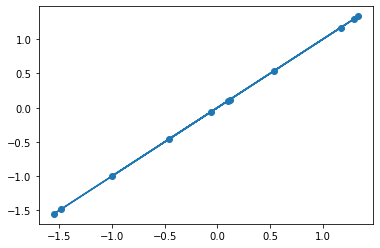

In [7]:
Wc_list = []
gamma_list = []
    
# for i in range(Niter):
X_exp, f_val, gp = ask_tell(data, result,data_param,
                        'Matern32', 'thompson_sampling', batch_size,  Wc_list, gamma_list) #thompson_sampling

X_ts_norm = (X_exp - np.mean(data, 0))/np.std(data, 0)
print(X_ts_norm)
Yp = gp.predict(X_ts_norm)
print(Yp)

In [8]:
column_names = []
for i in range(len(bounds)):
    column_names.append(data_param['bounds'][i]['name'])
    

X_exp[:,0:-1] = np.round(X_exp[:,0:-1])
X_exp[:,-1] = np.round(X_exp[:,-1],1)
X_exp_df = pd.DataFrame(X_exp)
X_exp_df.columns = column_names


X_exp_df.to_csv('./Arch1/Round1.csv')